# Experiment 1

In [2]:
import pandas as pd

# Load the dataset if 'df' is not already defined
if 'df' not in locals() and 'df' not in globals():
    df = pd.read_csv('6G_IoT_Beamforming_Dataset.csv')

# Define features for clustering
clustering_features = [
    'Obstacle Density', 'Mobility (m/s)',
    'Environment_Outdoor', 'Device Type_IoT Sensor'
]

# Ensure these features exist in the DataFrame
missing_clustering_cols = [col for col in clustering_features if col not in df.columns]
if missing_clustering_cols:
    raise ValueError(f"Missing clustering features in DataFrame: {missing_clustering_cols}")

X_clustering = df[clustering_features].copy()
display(X_clustering.head())

,Obstacle Density,Mobility (m/s),Environment_Outdoor,Device Type_IoT Sensor
0,6,2.612250,False,False
1,1,1.335916,True,False
2,9,1.544452,False,False
3,1,1.077700,False,True
4,5,1.778853,False,True


Next, I will preprocess the clustering features using the same numeric and categorical transformers defined earlier, as clustering algorithms often perform better with scaled data.

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer # Often useful for numeric transformers
from sklearn.pipeline import Pipeline # Import Pipeline

# Placeholder definitions for components assumed to be defined earlier
# or in a common preprocessing setup from the classification task.

# Define detect_column_types function
def detect_column_types(df, explicit_binary=False):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

    # Treat booleans as binary columns explicitly
    bin_cols = bool_cols

    # Remove binary columns from num_cols if they were initially included
    num_cols = [col for col in num_cols if col not in bin_cols]

    return num_cols, cat_cols, bin_cols

# Define explicit_binary flag
explicit_binary = True # Assuming this flag was used for specific binary column handling

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
binary_transformer = StandardScaler() # Scaling binary (0/1) features is also common

# The ColumnTransformer needs to be built for the clustering features
def build_clustering_preprocessor(X_df):
    num_cols, cat_cols, bin_cols = detect_column_types(X_df, explicit_binary=explicit_binary)

    # For clustering, we generally want all data to be numeric after preprocessing
    preprocessor_clustering = ColumnTransformer(transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
        ('bin', binary_transformer, bin_cols)
    ], remainder='drop')
    return preprocessor_clustering

preprocessor_clustering = build_clustering_preprocessor(X_clustering)
X_clustered_scaled = preprocessor_clustering.fit_transform(X_clustering)

print(f"Shape of preprocessed data for clustering: {X_clustered_scaled.shape}")

Shape of preprocessed data for clustering: (1000, 4)


Now, let's apply the K-Means clustering algorithm. We'll determine an optimal number of clusters using the Elbow method (Inertia) and Silhouette Score.

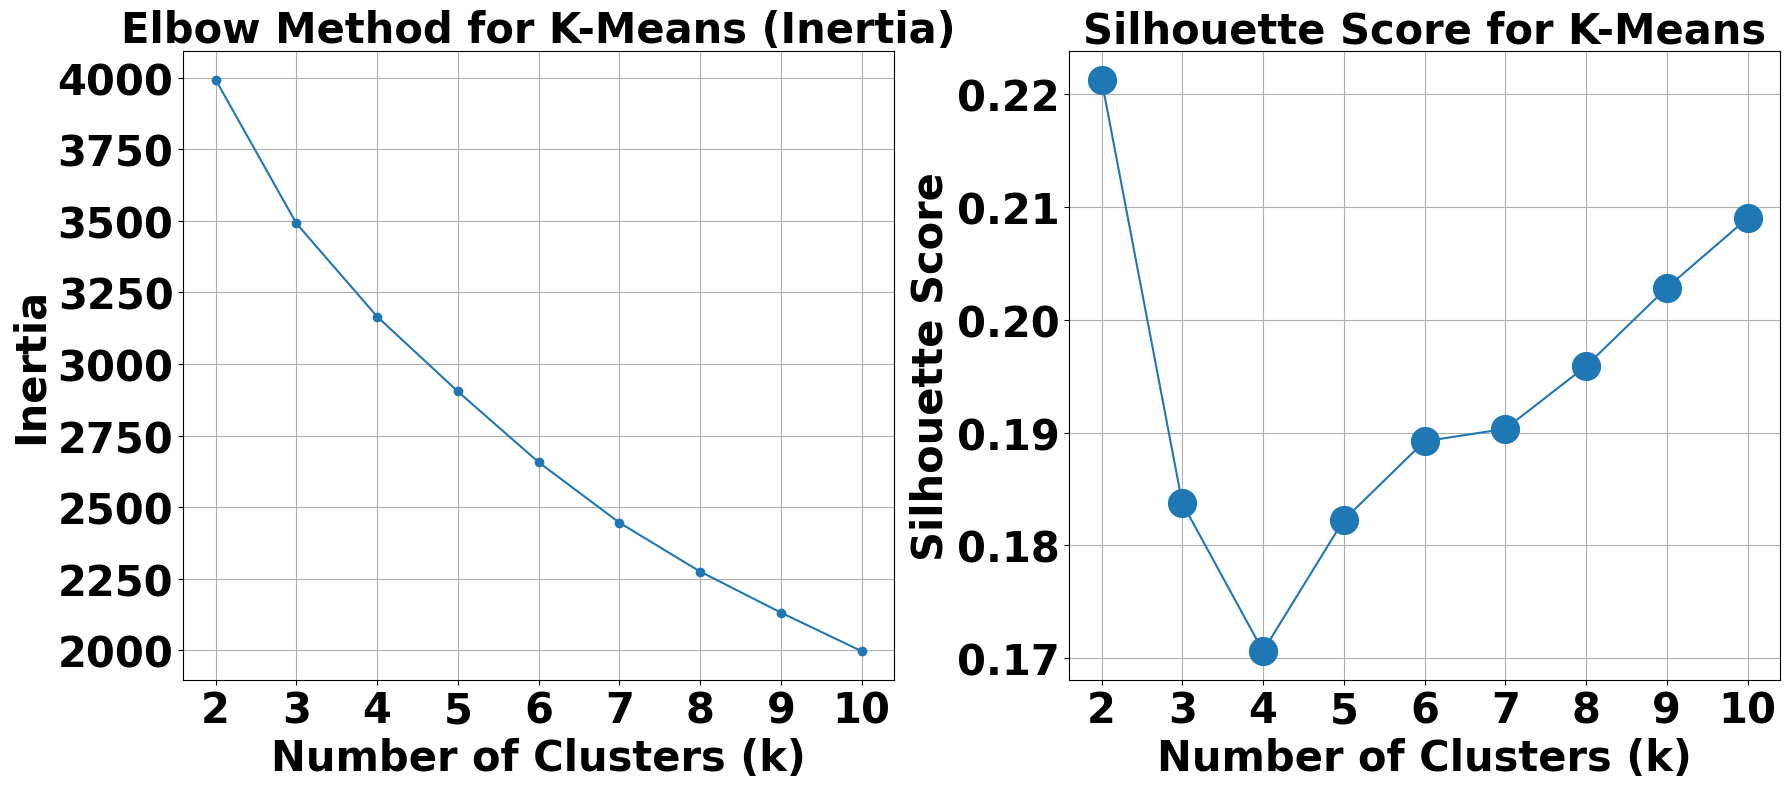

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for np.nan

RANDOM_STATE = 42 # Define RANDOM_STATE for reproducibility

# Determine optimal k using Elbow Method and Silhouette Score
# A range of k values to test
k_range = range(2, 11)
inertia_values = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_clustered_scaled)
    inertia_values.append(kmeans.inertia_)

    if k > 1:
        silhouette_scores.append(silhouette_score(X_clustered_scaled, kmeans.labels_))
    else:
        silhouette_scores.append(np.nan) # Silhouette score not defined for k=1

# Plotting Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].plot(k_range, inertia_values, marker='o', zorder=2)
axes[0].set_title('Elbow Method for K-Means (Inertia)', fontsize=30, fontweight="bold")
axes[0].set_xlabel('Number of Clusters (k)', fontsize=30, fontweight="bold")
axes[0].set_ylabel('Inertia', fontsize=30, fontweight="bold")
plt.setp(axes[0].get_xticklabels(), fontsize=30, fontweight="bold")
plt.setp(axes[0].get_yticklabels(), fontsize=30, fontweight="bold")
axes[0].grid(True)

# Plotting Silhouette Scores
axes[1].plot(k_range, silhouette_scores, marker='o', markersize=20)
axes[1].set_title('Silhouette Score for K-Means', fontsize=30, fontweight="bold")
axes[1].set_xlabel('Number of Clusters (k)', fontsize=30, fontweight="bold")
axes[1].set_ylabel('Silhouette Score', fontsize=30, fontweight="bold")
plt.setp(axes[1].get_xticklabels(), fontsize=30, fontweight="bold")
plt.setp(axes[1].get_yticklabels(), fontsize=30, fontweight="bold")
axes[1].grid(True)

plt.tight_layout()
plt.show()


Based on the plots above, k=4 seems to be a reasonable choice for K-Means, as it represents a good balance where the inertia reduction starts to diminish, and the silhouette score is relatively high.

Let's apply K-Means with n_clusters=4 and evaluate it, then proceed with DBSCAN and Hierarchical Clustering.

K-Means: Found 4 clusters (including noise if any for comparison).
DBSCAN: Found 5 clusters, with 6 noise points.
Hierarchical: Found 4 clusters.

--- Evaluating Clustering Algorithms ---


,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.352121,1.319662
1,DBSCAN,0.312782,1.204159
2,Hierarchical,0.352121,1.319662


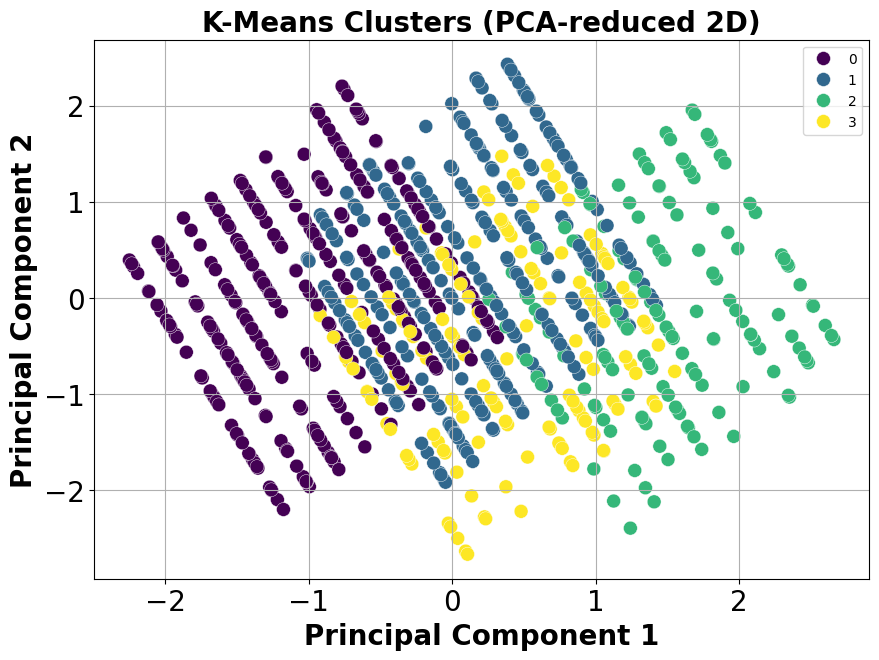

In [8]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# --- K-Means Clustering ---
optimal_k = 4 # Based on Elbow and Silhouette plots (from previous analysis)
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clustered_scaled)

# --- DBSCAN Clustering ---
# DBSCAN parameters (eps, min_samples) often require tuning.
# For initial features, min_samples was 2 * 4 = 8. Eps was initially 0.5
min_samples_dbscan = 2 * X_clustered_scaled.shape[1] # Recalculate based on current X_clustered_scaled dimensions
dbscan = DBSCAN(eps=0.5, min_samples=min_samples_dbscan) # eps might need adjustment based on data density
dbscan_labels = dbscan.fit_predict(X_clustered_scaled)

# --- Hierarchical Clustering (Agglomerative) ---
# We'll use the same optimal_k as K-Means for consistency in comparison.
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(X_clustered_scaled)

print(f"K-Means: Found {len(np.unique(kmeans_labels))} clusters (including noise if any for comparison).")
print(f"DBSCAN: Found {len(np.unique([l for l in dbscan_labels if l != -1]))} clusters, with {np.sum(dbscan_labels == -1)} noise points.")
print(f"Hierarchical: Found {len(np.unique(hierarchical_labels))} clusters.")

clustering_results = pd.DataFrame({
    'Algorithm': [],
    'Silhouette Score': [],
    'Davies-Bouldin Index': []
})

def evaluate_clustering(algorithm_name, labels, X_scaled):
    if len(np.unique(labels)) > 1:
        # Exclude noise points (-1) for silhouette score if present
        if -1 in labels:
            # Filter out noise points for evaluation
            filtered_X = X_scaled[labels != -1]
            filtered_labels = labels[labels != -1]
            if len(np.unique(filtered_labels)) > 1:
                sil_score = silhouette_score(filtered_X, filtered_labels)
                db_index = davies_bouldin_score(filtered_X, filtered_labels)
            else:
                sil_score = np.nan # Cannot calculate for a single cluster
                db_index = np.nan
        else:
            sil_score = silhouette_score(X_scaled, labels)
            db_index = davies_bouldin_score(X_scaled, labels)
    else:
        sil_score = np.nan # Cannot calculate for a single cluster
        db_index = np.nan

    global clustering_results
    clustering_results = pd.concat([
        clustering_results,
        pd.DataFrame([{
            'Algorithm': algorithm_name,
            'Silhouette Score': sil_score,
            'Davies-Bouldin Index': db_index
        }])
    ], ignore_index=True)


print("\n--- Evaluating Clustering Algorithms ---")
evaluate_clustering('K-Means', kmeans_labels, X_clustered_scaled)
evaluate_clustering('DBSCAN', dbscan_labels, X_clustered_scaled)
evaluate_clustering('Hierarchical', hierarchical_labels, X_clustered_scaled)

display(clustering_results)

# Optional: Visualize the clusters for K-Means (example with 2 principal components)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustered_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', legend='full', s=100, linewidth=0.3)
plt.title('K-Means Clusters (PCA-reduced 2D)', fontsize=20, fontweight="bold") # Increased font size for better visibility
plt.xlabel('Principal Component 1', fontsize=20, fontweight="bold")
plt.ylabel('Principal Component 2', fontsize=20, fontweight="bold")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.show()

### Interpreting K-Means Clusters from the Initial Feature Set

In [11]:
# Add the K-Means cluster labels (from the initial feature set) back to the original (unscaled) X_clustering DataFrame
initial_clustering_features = [
    'Obstacle Density', 'Mobility (m/s)',
    'Environment_Outdoor', 'Device Type_IoT Sensor'
] # Define the initial features
X_clustering_initial_with_labels = df[initial_clustering_features].copy()
X_clustering_initial_with_labels['Cluster'] = kmeans_labels

# Calculate the mean of each feature for each cluster
cluster_centers_initial_features = X_clustering_initial_with_labels.groupby('Cluster').mean()

display(cluster_centers_initial_features)

print("\n--- Interpretation of Initial K-Means Clusters ---")
for i, row in cluster_centers_initial_features.iterrows():
    print(f"\nCluster {i}:")
    print(f"- Average Obstacle Density: {row['Obstacle Density']:.2f}")
    print(f"- Average Mobility (m/s): {row['Mobility (m/s)']:.2f}")
    print(f"- Environment Outdoor Presence (avg 0-1): {row['Environment_Outdoor']:.2f}")
    print(f"- IoT Sensor Device Presence (avg 0-1): {row['Device Type_IoT Sensor']:.2f}")

,Obstacle Density,Mobility (m/s),Environment_Outdoor,Device Type_IoT Sensor
Cluster,,,,
0,5.050420,1.546818,1.0,0.0
1,4.867868,1.477463,0.0,0.0
2,4.770701,1.499561,0.0,1.0
3,4.862745,1.415139,1.0,1.0



--- Interpretation of Initial K-Means Clusters ---

Cluster 0:
- Average Obstacle Density: 5.05
- Average Mobility (m/s): 1.55
- Environment Outdoor Presence (avg 0-1): 1.00
- IoT Sensor Device Presence (avg 0-1): 0.00

Cluster 1:
- Average Obstacle Density: 4.87
- Average Mobility (m/s): 1.48
- Environment Outdoor Presence (avg 0-1): 0.00
- IoT Sensor Device Presence (avg 0-1): 0.00

Cluster 2:
- Average Obstacle Density: 4.77
- Average Mobility (m/s): 1.50
- Environment Outdoor Presence (avg 0-1): 0.00
- IoT Sensor Device Presence (avg 0-1): 1.00

Cluster 3:
- Average Obstacle Density: 4.86
- Average Mobility (m/s): 1.42
- Environment Outdoor Presence (avg 0-1): 1.00
- IoT Sensor Device Presence (avg 0-1): 1.00


# Experiment 2

Feature Selection for Clustering using SelectKBest

*   To ensure we are using the most relevant features for clustering, we will employ SelectKBest with the f_classif scoring function. This method identifies the features with the highest ANOVA F-value, indicating the strongest statistical relationship with the binary target variable 'Optimized'. This approach helps in selecting features that have discriminative power, which can be beneficial for forming meaningful clusters, even though clustering is an unsupervised task.

*   We will preprocess the features using the same ColumnTransformer setup as in the classification task to handle numerical and categorical data appropriately before applying SelectKBest. We'll select the top 5 features as an initial choice, which can be adjusted if needed.

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer

# Assuming 'Optimized' is the target column for the classification task
# Define X and y for feature selection
X = df.drop('Optimized', axis=1) # df should be available from earlier cells
y = df['Optimized']

# Define build_preprocessor using the same logic and components as build_clustering_preprocessor
# but applied to the full feature set X
def build_preprocessor(X_df):
    num_cols, cat_cols, bin_cols = detect_column_types(X_df, explicit_binary=explicit_binary)

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
        ('bin', binary_transformer, bin_cols)
    ], remainder='drop')
    return preprocessor

preprocessor_for_kbest = build_preprocessor(X)
X_processed_for_kbest = preprocessor_for_kbest.fit_transform(X)

# Get feature names after preprocessing using ColumnTransformer's own method
feature_names_out = preprocessor_for_kbest.get_feature_names_out()

k_features_to_select = 5 # Number of top features to select for clustering

selector = SelectKBest(f_classif, k='all') # Use 'all' to get scores for all features initially
selector.fit(X_processed_for_kbest, y)

# Map scores back to original feature names for better interpretation
feature_scores_map = {}

# We need the original column types to correctly map back
num_cols_X, cat_cols_X, bin_cols_X = detect_column_types(X, explicit_binary=explicit_binary)

for i, score in enumerate(selector.scores_):
    transformed_feature_name = feature_names_out[i]
    original_feature_name = None

    # Check numeric features
    if transformed_feature_name.startswith('num__'):
        original_feature_name = transformed_feature_name[5:]
    # Check binary features
    elif transformed_feature_name.startswith('bin__'):
        original_feature_name = transformed_feature_name[5:]
    # Check categorical features (one-hot encoded)
    elif transformed_feature_name.startswith('cat__'):
        # Iterate through original categorical columns to find a match
        for col in cat_cols_X:
            if transformed_feature_name.startswith(f'cat__{col}_'):
                original_feature_name = col
                break

    if original_feature_name:
        # Take the maximum score if an original feature is represented by multiple OHE columns
        feature_scores_map[original_feature_name] = max(feature_scores_map.get(original_feature_name, 0), score)

# Sort features by their scores and pick top k_features_to_select
sorted_features_by_score = sorted(feature_scores_map.items(), key=lambda item: item[1], reverse=True)

selected_clustering_features_with_scores = sorted_features_by_score[:k_features_to_select]
selected_clustering_features_names = [item[0] for item in selected_clustering_features_with_scores]

print(f"\nTop {k_features_to_select} features selected by SelectKBest and their scores (mapped to original feature names):")
for feature_name, score in selected_clustering_features_with_scores:
    print(f"- {feature_name}: {score:.2f}")

# Update the clustering_features list with the newly selected features
clustering_features = selected_clustering_features_names

print(f"\nUpdated clustering_features: {clustering_features}")


Top 5 features selected by SelectKBest and their scores (mapped to original feature names):
- Latency (ms): 212.27
- Throughput (Mbps): 153.38
- Beamforming Gain (dB): 72.67
- Device Type_Smartphone: 2.33
- SNR Improvement (dB): 1.59

Updated clustering_features: ['Latency (ms)', 'Throughput (Mbps)', 'Beamforming Gain (dB)', 'Device Type_Smartphone', 'SNR Improvement (dB)']


### Re-running Clustering with Selected Features

Now, let's re-run the clustering algorithms and evaluation using the top 5 features selected by `SelectKBest`.

In [13]:
# Update X_clustering with the newly selected features
missing_clustering_cols = [col for col in clustering_features if col not in df.columns]
if missing_clustering_cols:
    raise ValueError(f"Missing clustering features in DataFrame: {missing_clustering_cols}")

X_clustering = df[clustering_features].copy()

# Re-build the preprocessor for the updated clustering features
preprocessor_clustering = build_clustering_preprocessor(X_clustering)
X_clustered_scaled = preprocessor_clustering.fit_transform(X_clustering)

print(f"Shape of preprocessed data for clustering with selected features: {X_clustered_scaled.shape}")

Shape of preprocessed data for clustering with selected features: (1000, 5)


#### Determine Optimal K-Means Clusters with New Features

Let's re-evaluate the optimal number of clusters for K-Means using the Elbow method and Silhouette Score with the refined feature set.

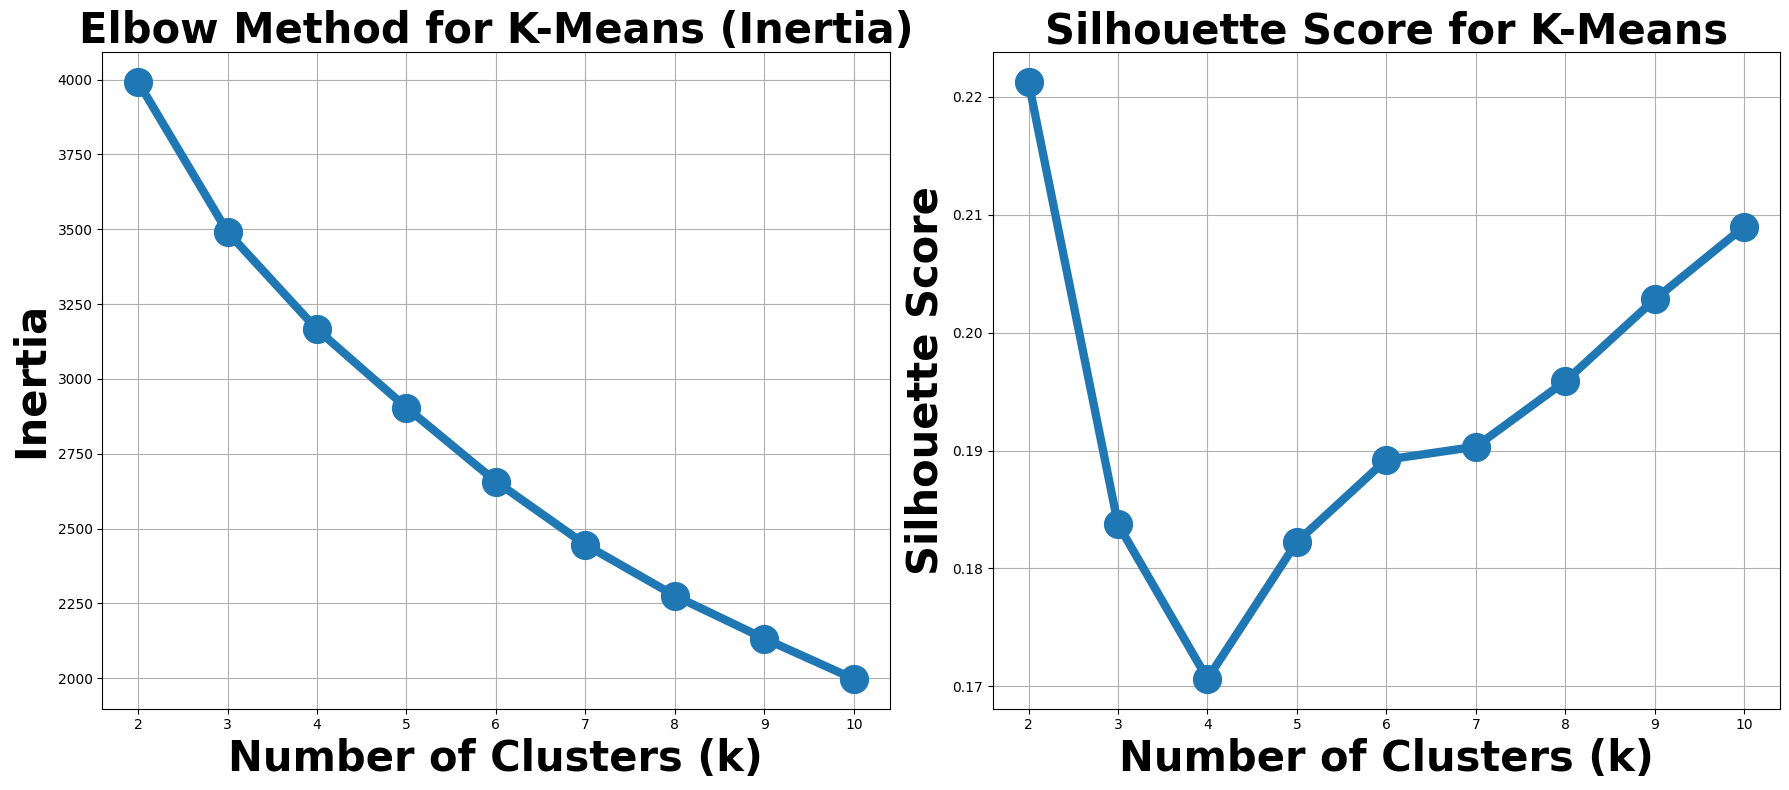

In [17]:
# Determine optimal k using Elbow Method and Silhouette Score with new features
k_range = range(2, 11)
inertia_values_new = []
silhouette_scores_new = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_clustered_scaled)
    inertia_values_new.append(kmeans.inertia_)

    if k > 1:
        silhouette_scores_new.append(silhouette_score(X_clustered_scaled, kmeans.labels_))
    else:
        silhouette_scores_new.append(np.nan) # Silhouette score not defined for k=1

# Plotting Elbow Method
fig_new, axes_new = plt.subplots(1, 2, figsize=(18, 8))

axes_new[0].plot(k_range, inertia_values_new, marker='o', linewidth=6, markersize=20)
axes_new[0].set_title('Elbow Method for K-Means (Inertia)', fontsize=30, fontweight="bold")
axes_new[0].set_xlabel('Number of Clusters (k)', fontsize=30, fontweight="bold")
axes_new[0].set_ylabel('Inertia', fontsize=30, fontweight="bold")
#plt.xticks(fontsize=20, fontweight="bold")
#plt.yticks(fontsize=20, fontweight="bold")
plt.setp(axes[0].get_xticklabels(), fontsize=30, fontweight="bold")
plt.setp(axes[0].get_yticklabels(), fontsize=30, fontweight="bold")

axes_new[0].grid(True)

# Plotting Silhouette Scores
axes_new[1].plot(k_range, silhouette_scores_new, marker='o', linewidth=6, markersize=20)
axes_new[1].set_title('Silhouette Score for K-Means', fontsize=30, fontweight="bold")
axes_new[1].set_xlabel('Number of Clusters (k)', fontsize=30, fontweight="bold")
axes_new[1].set_ylabel('Silhouette Score', fontsize=30, fontweight="bold")
plt.setp(axes[1].get_xticklabels(), fontsize=30, fontweight="bold")
plt.setp(axes[1].get_yticklabels(), fontsize=30, fontweight="bold")
#plt.xticks(fontsize=20, fontweight="bold")
#plt.yticks(fontsize=20, fontweight="bold")
axes_new[1].grid(True)


plt.tight_layout()
plt.show()

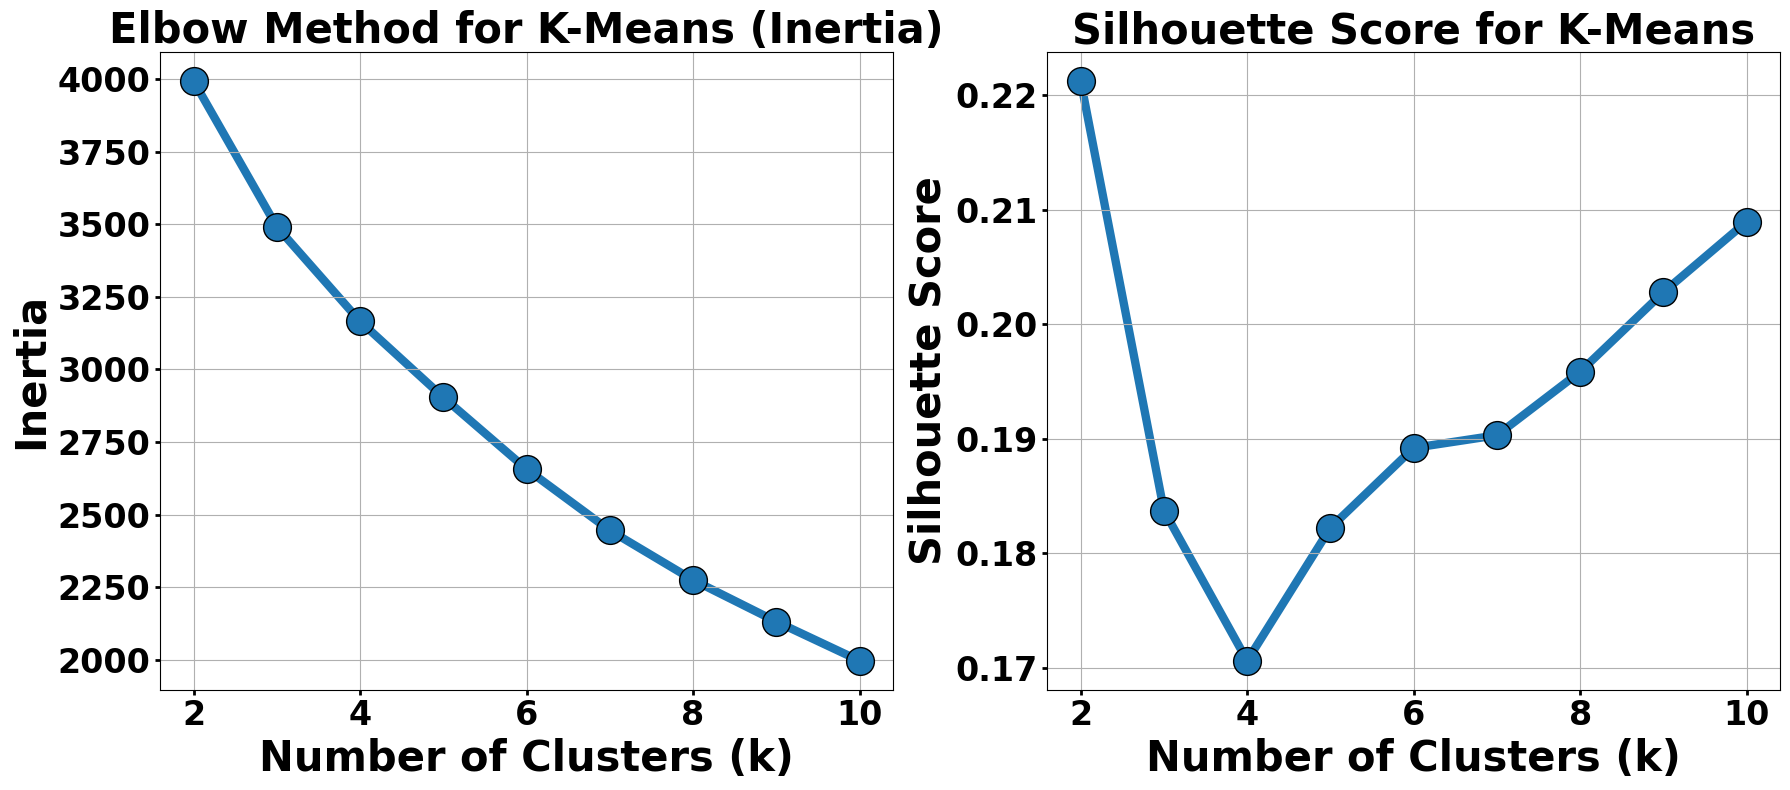

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Assuming X_clustered_scaled and RANDOM_STATE are already defined

k_range = range(2, 11)
inertia_values_new = []
silhouette_scores_new = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_clustered_scaled)
    inertia_values_new.append(kmeans.inertia_)
    if k > 1:
        silhouette_scores_new.append(silhouette_score(X_clustered_scaled, kmeans.labels_))
    else:
        silhouette_scores_new.append(np.nan)

fig_new, axes_new = plt.subplots(1, 2, figsize=(18, 8))

# --- Elbow plot ---
# Plot bold line first, then overlay big, crisp markers
axes_new[0].plot(k_range, inertia_values_new, linestyle='-', linewidth=6, color='C0', zorder=1)
axes_new[0].plot(k_range, inertia_values_new, marker='o', linestyle='', markersize=20, markeredgecolor='k', markerfacecolor='C0', zorder=2)
axes_new[0].set_title('Elbow Method for K-Means (Inertia)', fontsize=30, fontweight="bold")
axes_new[0].set_xlabel('Number of Clusters (k)', fontsize=30, fontweight="bold")
axes_new[0].set_ylabel('Inertia', fontsize=30, fontweight="bold")
axes_new[0].grid(True)

# --- Silhouette plot ---
axes_new[1].plot(k_range, silhouette_scores_new, linestyle='-', linewidth=6, color='C0', zorder=1)
axes_new[1].plot(k_range, silhouette_scores_new, marker='o', linestyle='', markersize=20, markeredgecolor='k', markerfacecolor='C0', zorder=2)
axes_new[1].set_title('Silhouette Score for K-Means', fontsize=30, fontweight="bold")
axes_new[1].set_xlabel('Number of Clusters (k)', fontsize=30, fontweight="bold")
axes_new[1].set_ylabel('Silhouette Score', fontsize=30, fontweight="bold")
axes_new[1].grid(True)

# Make ticks bold and large for both axes of both subplots
for ax in axes_new:
    ax.tick_params(axis='both', which='major', labelsize=24, width=2)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

Based on the updated plots, we will choose an optimal `k` for K-Means. Then, we apply all three clustering algorithms and evaluate them.

K-Means (New Features): Found 4 clusters.
DBSCAN (New Features): Found 0 clusters, with 1000 noise points.
Hierarchical (New Features): Found 4 clusters.

--- Evaluating Clustering Algorithms with Selected Features ---


,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means (Selected Features),0.170634,1.621394
1,DBSCAN (Selected Features),NaN,NaN
2,Hierarchical (Selected Features),0.142313,1.808506


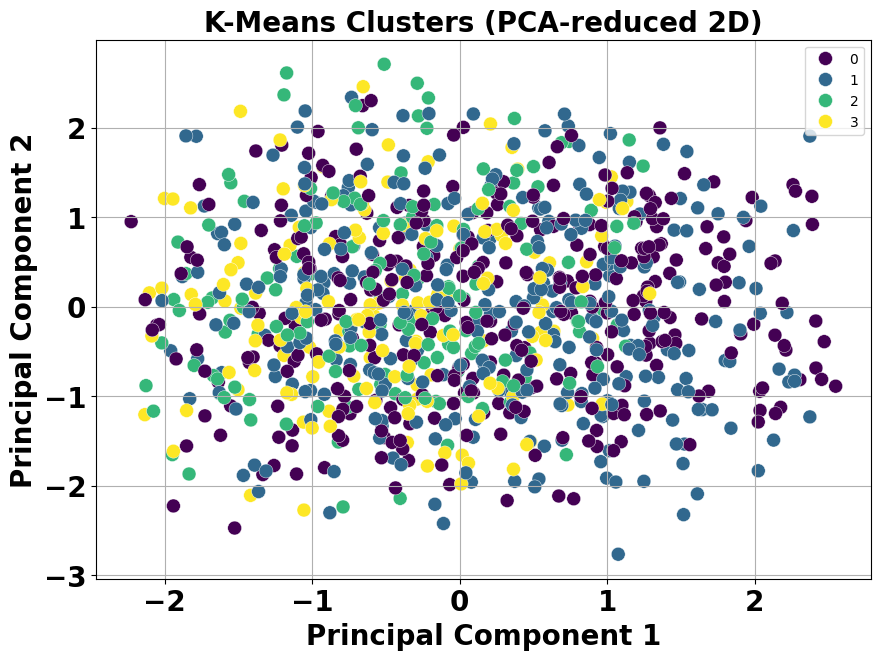

In [37]:
optimal_k_new = 4 # Based on the re-evaluated Elbow and Silhouette plots (adjust if needed)

# --- K-Means Clustering with New Features ---
kmeans_new = KMeans(n_clusters=optimal_k_new, random_state=RANDOM_STATE, n_init=10)
kmeans_labels_new = kmeans_new.fit_predict(X_clustered_scaled)

# --- DBSCAN Clustering with New Features ---
min_samples_dbscan_new = 2 * X_clustered_scaled.shape[1]
dbscan_new = DBSCAN(eps=0.5, min_samples=min_samples_dbscan_new)
dbscan_labels_new = dbscan_new.fit_predict(X_clustered_scaled)

# --- Hierarchical Clustering (Agglomerative) with New Features ---
hierarchical_new = AgglomerativeClustering(n_clusters=optimal_k_new)
hierarchical_labels_new = hierarchical_new.fit_predict(X_clustered_scaled)

print(f"K-Means (New Features): Found {len(np.unique(kmeans_labels_new))} clusters.")
print(f"DBSCAN (New Features): Found {len(np.unique([l for l in dbscan_labels_new if l != -1]))} clusters, with {np.sum(dbscan_labels_new == -1)} noise points.")
print(f"Hierarchical (New Features): Found {len(np.unique(hierarchical_labels_new))} clusters.")

# Re-initialize clustering_results for comparison
clustering_results_new = pd.DataFrame({
    'Algorithm': [],
    'Silhouette Score': [],
    'Davies-Bouldin Index': []
})

def evaluate_clustering_new(algorithm_name, labels, X_scaled):
    if len(np.unique(labels)) > 1:
        if -1 in labels:
            filtered_X = X_scaled[labels != -1]
            filtered_labels = labels[labels != -1]
            if len(np.unique(filtered_labels)) > 1:
                sil_score = silhouette_score(filtered_X, filtered_labels)
                db_index = davies_bouldin_score(filtered_X, filtered_labels)
            else:
                sil_score = np.nan
                db_index = np.nan
        else:
            sil_score = silhouette_score(X_scaled, labels)
            db_index = davies_bouldin_score(X_scaled, labels)
    else:
        sil_score = np.nan
        db_index = np.nan

    global clustering_results_new
    clustering_results_new = pd.concat([
        clustering_results_new,
        pd.DataFrame([{
            'Algorithm': algorithm_name,
            'Silhouette Score': sil_score,
            'Davies-Bouldin Index': db_index
        }])
    ], ignore_index=True)

print("\n--- Evaluating Clustering Algorithms with Selected Features ---")
evaluate_clustering_new('K-Means (Selected Features)', kmeans_labels_new, X_clustered_scaled)
evaluate_clustering_new('DBSCAN (Selected Features)', dbscan_labels_new, X_clustered_scaled)
evaluate_clustering_new('Hierarchical (Selected Features)', hierarchical_labels_new, X_clustered_scaled)

display(clustering_results_new)

# Visualize the clusters for K-Means (example with 2 principal components) with new features
pca_new = PCA(n_components=2)
X_pca_new = pca_new.fit_transform(X_clustered_scaled)

#plt.figure(figsize=(10, 7))
#sns.scatterplot(x=X_pca_new[:, 0], y=X_pca_new[:, 1], hue=kmeans_labels_new, palette='viridis', legend='full')
#plt.title('K-Means Clusters (PCA-reduced 2D) - Selected Features')
#plt.xlabel('Principal Component 1')
#plt.ylabel('Principal Component 2')
#plt.grid(True)
#plt.show()
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_new[:, 0], y=X_pca_new[:, 1], hue=kmeans_labels, palette='viridis', legend='full', s=100, linewidth=0.3)
plt.title('K-Means Clusters (PCA-reduced 2D)', fontsize=20, fontweight="bold") # Increased font size for better visibility
plt.xlabel('Principal Component 1', fontsize=20, fontweight="bold")
plt.ylabel('Principal Component 2', fontsize=20, fontweight="bold")
plt.xticks(fontsize=20, fontweight="bold")
plt.yticks(fontsize=20, fontweight="bold")
plt.grid(True)
plt.show()

### Comparing Feature Importance: Initial vs. Selected Features

In [19]:
print('--- Initial Clustering Features Importance ---')
initial_clustering_features = [
    'Obstacle Density', 'Mobility (m/s)',
    'Environment_Outdoor', 'Device Type_IoT Sensor'
]

X_initial_clustering = df[initial_clustering_features].copy()

preprocessor_for_initial_kbest = build_preprocessor(X_initial_clustering)
X_processed_for_initial_kbest = preprocessor_for_initial_kbest.fit_transform(X_initial_clustering)

feature_names_out_initial = preprocessor_for_initial_kbest.get_feature_names_out()

selector_initial = SelectKBest(f_classif, k='all')
selector_initial.fit(X_processed_for_initial_kbest, y)

feature_scores_map_initial = {}
num_cols_initial, cat_cols_initial, bin_cols_initial = detect_column_types(X_initial_clustering, explicit_binary=explicit_binary)

for i, score in enumerate(selector_initial.scores_):
    transformed_feature_name = feature_names_out_initial[i]
    original_feature_name = None

    if transformed_feature_name.startswith('num__'):
        original_feature_name = transformed_feature_name[5:]
    elif transformed_feature_name.startswith('bin__'):
        original_feature_name = transformed_feature_name[5:]
    elif transformed_feature_name.startswith('cat__'):
        for col in cat_cols_initial:
            if transformed_feature_name.startswith(f'cat__{col}_'):
                original_feature_name = col
                break

    if original_feature_name:
        feature_scores_map_initial[original_feature_name] = max(feature_scores_map_initial.get(original_feature_name, 0), score)

sorted_initial_features_by_score = sorted(feature_scores_map_initial.items(), key=lambda item: item[1], reverse=True)

for feature_name, score in sorted_initial_features_by_score:
    print(f"- {feature_name}: {score:.2f}")

print('\n--- Newly Selected Clustering Features Importance ---')
for feature_name, score in selected_clustering_features_with_scores:
    print(f"- {feature_name}: {score:.2f}")

--- Initial Clustering Features Importance ---
- Mobility (m/s): 1.18
- Environment_Outdoor: 0.81
- Device Type_IoT Sensor: 0.56
- Obstacle Density: 0.00

--- Newly Selected Clustering Features Importance ---
- Latency (ms): 212.27
- Throughput (Mbps): 153.38
- Beamforming Gain (dB): 72.67
- Device Type_Smartphone: 2.33
- SNR Improvement (dB): 1.59


### Visualizing K-Distance Graph for DBSCAN `eps` Tuning (New Features)

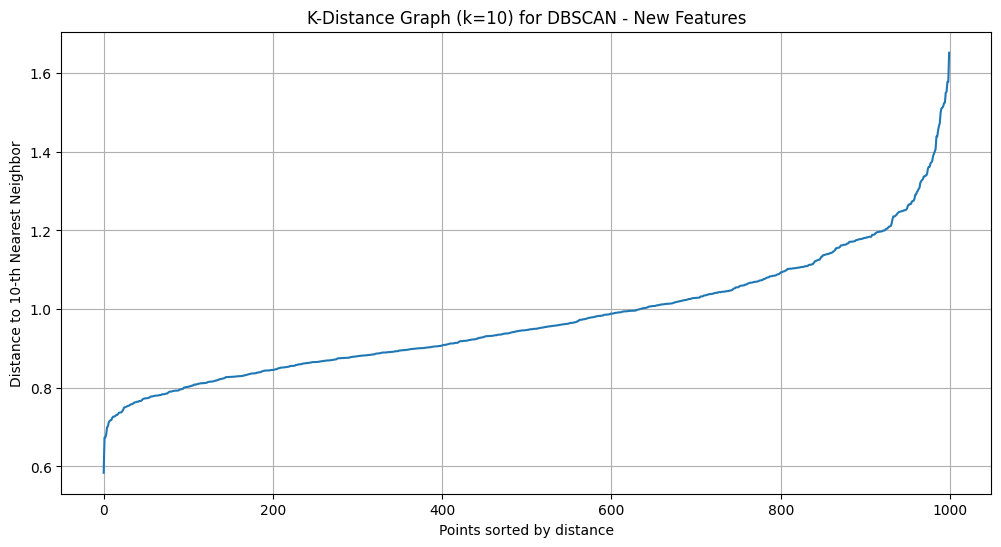

Based on this graph, look for the 'elbow' point to determine a suitable `eps` value.


In [20]:
from sklearn.neighbors import NearestNeighbors

# min_samples_dbscan_new was calculated as 2 * number of features = 2 * 5 = 10
# We will calculate the distance to the (k-1)th nearest neighbor, so k is min_samples_dbscan_new
k_for_distance = min_samples_dbscan_new # k for the k-distance graph

# Find the k-nearest neighbors for each point
# n_neighbors should be k_for_distance + 1 because the point itself is included in neighbors
neigh = NearestNeighbors(n_neighbors=k_for_distance + 1)
neigh.fit(X_clustered_scaled)

distances, indices = neigh.kneighbors(X_clustered_scaled)

# Sort distances to the k-th nearest neighbor
# We are interested in the distance to the k_for_distance-th neighbor (index k_for_distance - 1 in 0-indexed array)
# The first column is distance to itself (0), so we take the k_for_distance-th column (index k_for_distance)
k_distances = np.sort(distances[:, k_for_distance], axis=0)

# Plot the k-distance graph
plt.figure(figsize=(12, 6))
plt.plot(k_distances)
plt.title(f'K-Distance Graph (k={k_for_distance}) for DBSCAN - New Features')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {k_for_distance}-th Nearest Neighbor')
plt.grid(True)
plt.show()

print(f"Based on this graph, look for the 'elbow' point to determine a suitable `eps` value.")

### Re-running DBSCAN with Tuned `eps` (New Features)

Re-running DBSCAN with eps=0.8 and min_samples=10
DBSCAN (Tuned eps): Found 15 clusters, with 425 noise points.


,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means (Selected Features),0.170634,1.621394
1,DBSCAN (Selected Features),NaN,NaN
2,Hierarchical (Selected Features),0.142313,1.808506
3,DBSCAN (Tuned eps),-0.085173,1.125584
4,DBSCAN (Tuned eps),-0.085173,1.125584


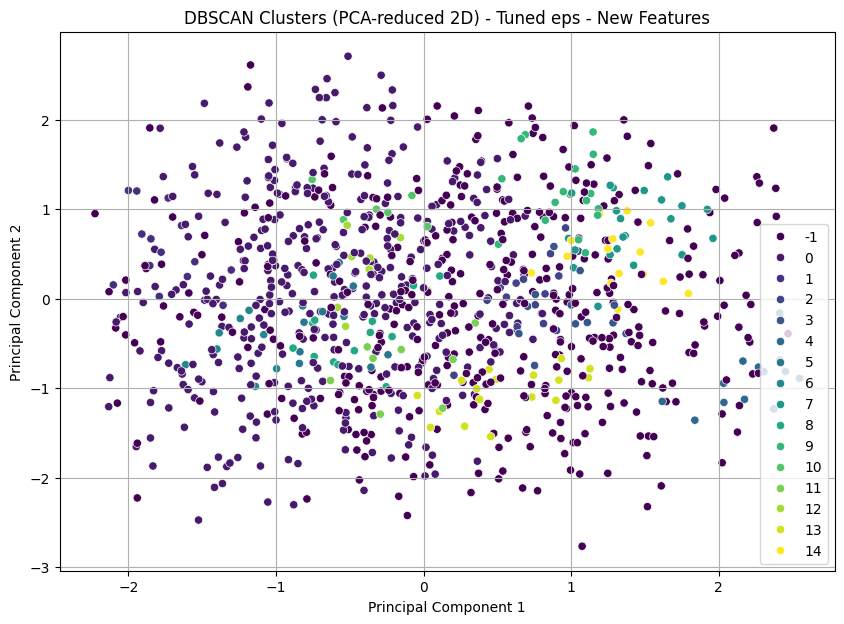

In [23]:
# @title Input your chosen `eps` value from the k-distance graph:
new_eps_dbscan = 0.8 # @param {type:"number"}

print(f"Re-running DBSCAN with eps={new_eps_dbscan} and min_samples={min_samples_dbscan_new}")

# --- DBSCAN Clustering with Tuned eps (New Features) ---
dbscan_tuned = DBSCAN(eps=new_eps_dbscan, min_samples=min_samples_dbscan_new)
dbscan_tuned_labels = dbscan_tuned.fit_predict(X_clustered_scaled)

print(f"DBSCAN (Tuned eps): Found {len(np.unique([l for l in dbscan_tuned_labels if l != -1]))} clusters, with {np.sum(dbscan_tuned_labels == -1)} noise points.")

# Evaluate the tuned DBSCAN
evaluate_clustering_new('DBSCAN (Tuned eps)', dbscan_tuned_labels, X_clustered_scaled)

display(clustering_results_new)

# Visualize the clusters for tuned DBSCAN (example with 2 principal components)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_new[:, 0], y=X_pca_new[:, 1], hue=dbscan_tuned_labels, palette='viridis', legend='full')
plt.title('DBSCAN Clusters (PCA-reduced 2D) - Tuned eps - New Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Summary Table of Clustering Performance (Initial vs. Selected Features)

In [22]:
# Combine the results from initial and new feature sets
summary_table = pd.concat([clustering_results, clustering_results_new], ignore_index=True)

# Display the summary table
display(summary_table.sort_values(by='Silhouette Score', ascending=False))

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.352121,1.319662
2,Hierarchical,0.352121,1.319662
1,DBSCAN,0.312782,1.204159
3,K-Means (Selected Features),0.170634,1.621394
5,Hierarchical (Selected Features),0.142313,1.808506
6,DBSCAN (Tuned eps),-0.085173,1.125584
4,DBSCAN (Selected Features),NaN,NaN
